### 1.2 Select and Download the dataset

Selected dataset: `RealWaste`

In [1]:
import requests
import zipfile
import io
import os
from tqdm import tqdm

# URL of the dataset
url = "https://archive.ics.uci.edu/static/public/908/realwaste.zip"

print("Starting download...")
# Download the dataset with progress bar
response = requests.get(url, stream=True)
total_size = int(response.headers.get('content-length', 0))
block_size = 1024  # 1 Kibibyte
tqdm_bar = tqdm(total=total_size, unit='iB', unit_scale=True)

with io.BytesIO() as file_buffer:
    for data in response.iter_content(block_size):
        tqdm_bar.update(len(data))
        file_buffer.write(data)
    tqdm_bar.close()
    file_buffer.seek(0)
    print("Download completed.")

    print("Extracting files...")
    with zipfile.ZipFile(file_buffer) as z:
        z.extractall("realwaste_dataset")
    print("Extraction completed.")

# List the files in the extracted dataset directory
extracted_files = os.listdir("realwaste_dataset")
print("Extracted files:", extracted_files)

Starting download...


689MiB [02:49, 4.06MiB/s] 


Download completed.
Extracting files...
Extraction completed.
Extracted files: ['realwaste-main']


### 1.3 Split dataset

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the dataset directory and categories
dataset_dir = "realwaste_dataset/realwaste-main/RealWaste"
categories = [
    "Cardboard", "Food Organics", "Glass", "Metal", "Miscellaneous Trash",
    "Paper", "Plastic", "Textile Trash", "Vegetation"
]

# Create a list to hold the file paths and labels
image_paths = []
labels = []

# Iterate over the categories and collect all image paths
for label, category in enumerate(categories):
    category_path = os.path.join(dataset_dir, category)
    
    # Collect all image files in the category folder
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        if os.path.isfile(image_path):  # Make sure it's a file
            image_paths.append(image_path)
            labels.append(label)  # Assign a numeric label to each category

# Split the dataset into 60% train, 20% validation, and 20% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.4, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42
)

# Function to copy files to a new directory
def copy_files(file_paths, labels, split_name, base_dir="split_data"):
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    # Create subfolders for each category
    for category in categories:
        os.makedirs(os.path.join(split_dir, category), exist_ok=True)
    
    for file_path, label in zip(file_paths, labels):
        category = categories[label]
        dest_dir = os.path.join(split_dir, category)
        shutil.copy(file_path, dest_dir)  # Copy image to the corresponding category folder

# Copy files to corresponding directories for training, validation, and test sets
copy_files(train_paths, train_labels, "train")
copy_files(val_paths, val_labels, "val")
copy_files(test_paths, test_labels, "test")

print("Dataset split completed:")
print(f"Training set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")
print(f"Testing set size: {len(test_paths)}")

# Delete the main dataset directory to save space
shutil.rmtree("realwaste_dataset")

print("\nMain dataset directory deleted.")

Dataset split completed:
Training set size: 2851
Validation set size: 950
Testing set size: 951

Main dataset directory deleted.


### 1.4 Bulid the CNN model

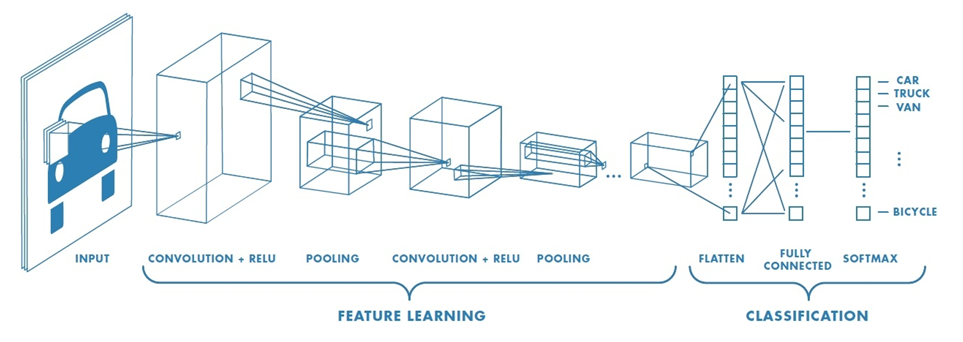

Learning rate: `0.001`

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = models.Sequential()

# Input layer
model.add(layers.Input(shape=(64, 64, 3)))  # Example: input image size 64x64 with 3 channels (RGB)

# First Convolutional layer: x1 filters, m1 x m1 kernel, activation function (ReLU)
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))

# MaxPooling layer
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional layer: x2 filters, m2 x m2 kernel, activation function (ReLU)
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))

# MaxPooling layer
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten the output for the fully connected layer
model.add(layers.Flatten())

# Fully connected layer with x3 units
model.add(layers.Dense(units=128, activation='relu'))

# Add dropout to reduce overfitting
model.add(layers.Dropout(0.5))  # Dropout rate of 50%

# Output layer: units equal to the number of classes (assuming 3 classes in this case)
model.add(layers.Dense(units=9, activation='softmax'))  # Example: 3 classes

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,313 (6.20 MB)

 Trainable params: 1,626,313 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

### 1.7 Train the model

Found 2851 images belonging to 9 classes.
Found 950 images belonging to 9 classes.


C:\Users\Asus\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - accuracy: 0.2218 - loss: 2.1110 - val_accuracy: 0.3579 - val_loss: 1.7937
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.3503 - loss: 1.7663 - val_accuracy: 0.3800 - val_loss: 1.6492
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.4128 - loss: 1.6215 - val_accuracy: 0.4663 - val_loss: 1.5188
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.4562 - loss: 1.5087 - val_accuracy: 0.4789 - val_loss: 1.4820
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.4922 - loss: 1.4386 - val_accuracy: 0.5126 - val_loss: 1.3743
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.5449 - loss: 1.3124 - val_accuracy: 0.5368 - val_loss: 1.3213
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 251ms/step - accuracy: 0.5793 - loss: 1.1703 - val_accuracy: 0.5358 - val_loss: 1.3682
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - accuracy: 0.5975 - loss: 1.1535 - val_accu

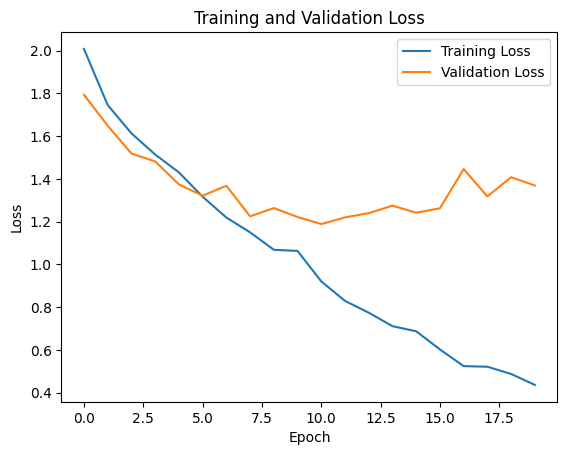

In [4]:
import matplotlib.pyplot as plt

# Define the data generators for training and validation sets
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'split_data/train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_directory(
    'split_data/val',
    target_size=(64, 64),
    batch_size=32,
    class_mode='sparse'
)

# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### 1.10 Evaluate the Model

Found 951 images belonging to 9 classes.


C:\Users\Asus\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.5791 - loss: 1.4561
Test Accuracy: 59.70%
Test Loss: 1.3842
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step


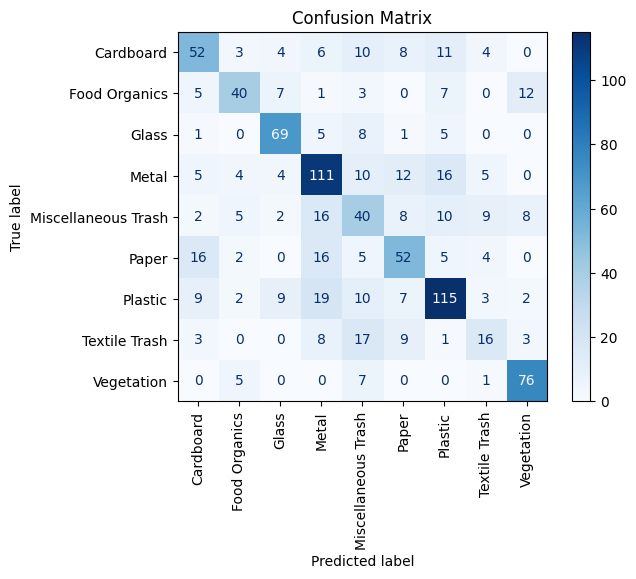


Precision for each class:
Cardboard: 0.5591
Food Organics: 0.6557
Glass: 0.7263
Metal: 0.6099
Miscellaneous Trash: 0.3636
Paper: 0.5361
Plastic: 0.6765
Textile Trash: 0.3810
Vegetation: 0.7525

Recall for each class:
Cardboard: 0.5306
Food Organics: 0.5333
Glass: 0.7753
Metal: 0.6647
Miscellaneous Trash: 0.4000
Paper: 0.5200
Plastic: 0.6534
Textile Trash: 0.2807
Vegetation: 0.8539


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up ImageDataGenerator for the testing data
test_datagen = ImageDataGenerator(rescale=1./255)

# Set up the directory for the testing data
test_dir = 'split_data/test'

# Create a test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),  # Resize images to 64x64
    batch_size=32,
    class_mode='sparse',  # Use sparse labels for integer labels
    shuffle=False  # Don't shuffle so we can map the predictions to the true labels
)

# Evaluate the model on the testing data
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Get the true labels and predictions
true_labels = test_generator.classes
predictions = model.predict(test_generator, steps=np.ceil(test_generator.samples / test_generator.batch_size).astype(int))

# Convert predictions from probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.title('Confusion Matrix')
plt.show()

# Precision and Recall for each class
precision = precision_score(true_labels, predicted_labels, average=None)
recall = recall_score(true_labels, predicted_labels, average=None)

print("\nPrecision for each class:")
for i, class_name in enumerate(test_generator.class_indices.keys()):
    print(f"{class_name}: {precision[i]:.4f}")

print("\nRecall for each class:")
for i, class_name in enumerate(test_generator.class_indices.keys()):
    print(f"{class_name}: {recall[i]:.4f}")


### 1.11 Plot training and validation loss for different learning rates such as 0.0001, 0.001, 0.01, and 0.1

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 286ms/step - accuracy: 0.1942 - loss: 2.1524 - val_accuracy: 0.3032 - val_loss: 2.0029
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 288ms/step - accuracy: 0.2918 - loss: 1.9692 - val_accuracy: 0.3358 - val_loss: 1.8221
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 295ms/step - accuracy: 0.3488 - loss: 1.8324 - val_accuracy: 0.3442 - val_loss: 1.7813
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.3686 - loss: 1.7526 - val_accuracy: 0.3747 - val_loss: 1.6818
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.3686 - loss: 1.7015 - val_accuracy: 0.3811 - val_loss: 1.6484
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - accuracy: 0.3969 - loss: 1.6627 - val_accuracy: 0.3895 - val_loss: 1.6099
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 265ms/step - accuracy: 0.4173 - loss: 1.6169 - val_accuracy: 0.4242 - val_loss: 1.5742
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 265ms/step - accuracy: 0.4366 - loss: 1.5678 - val_accu

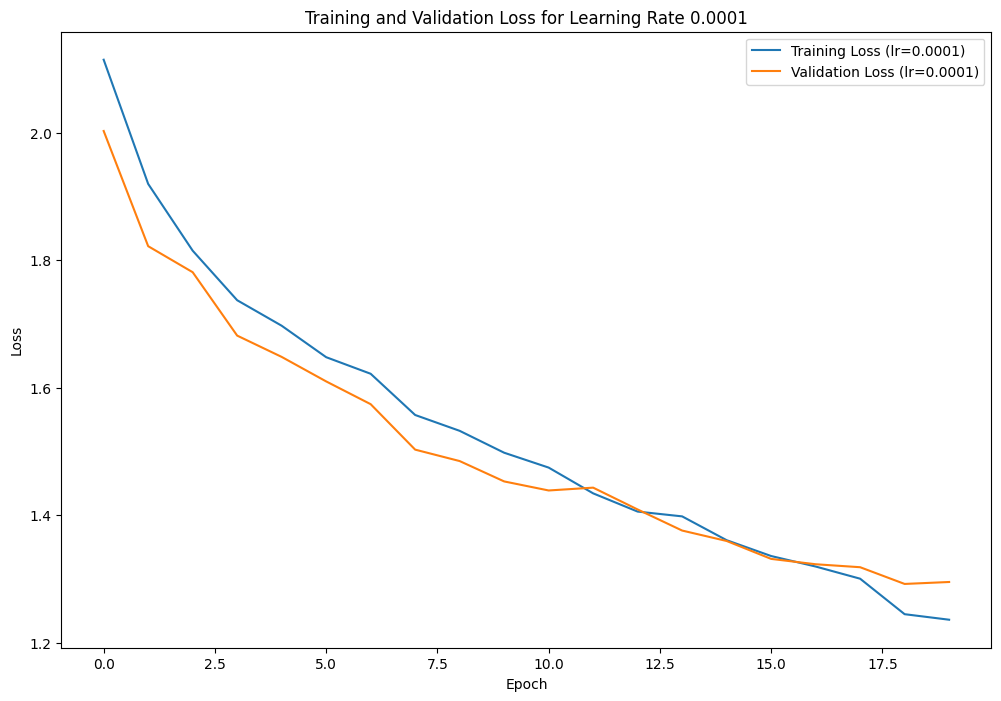

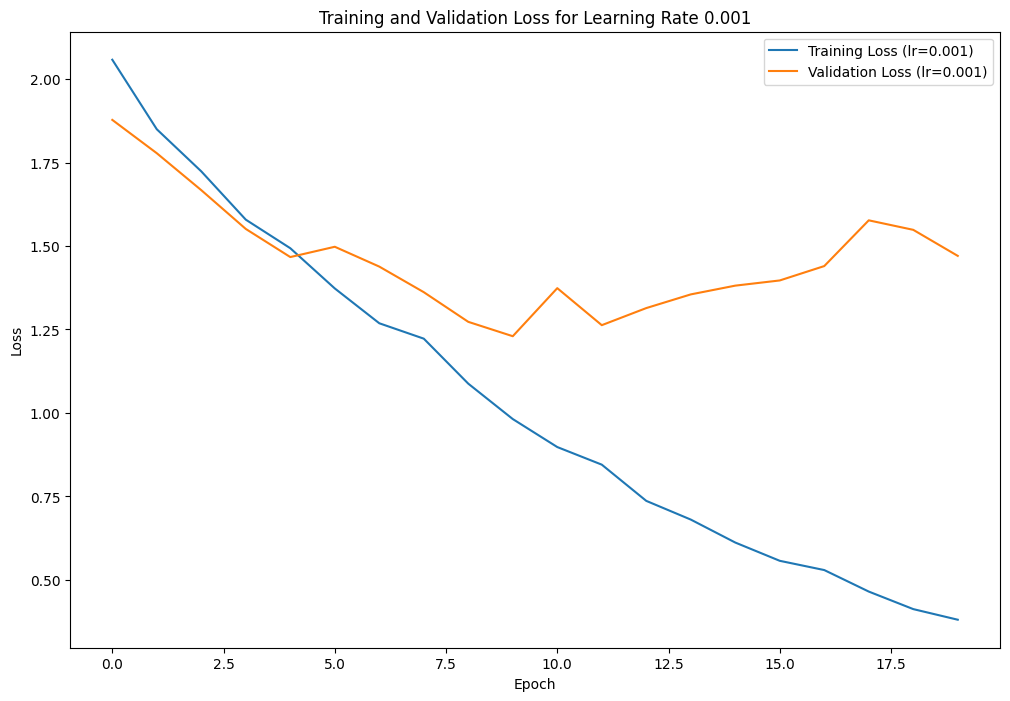

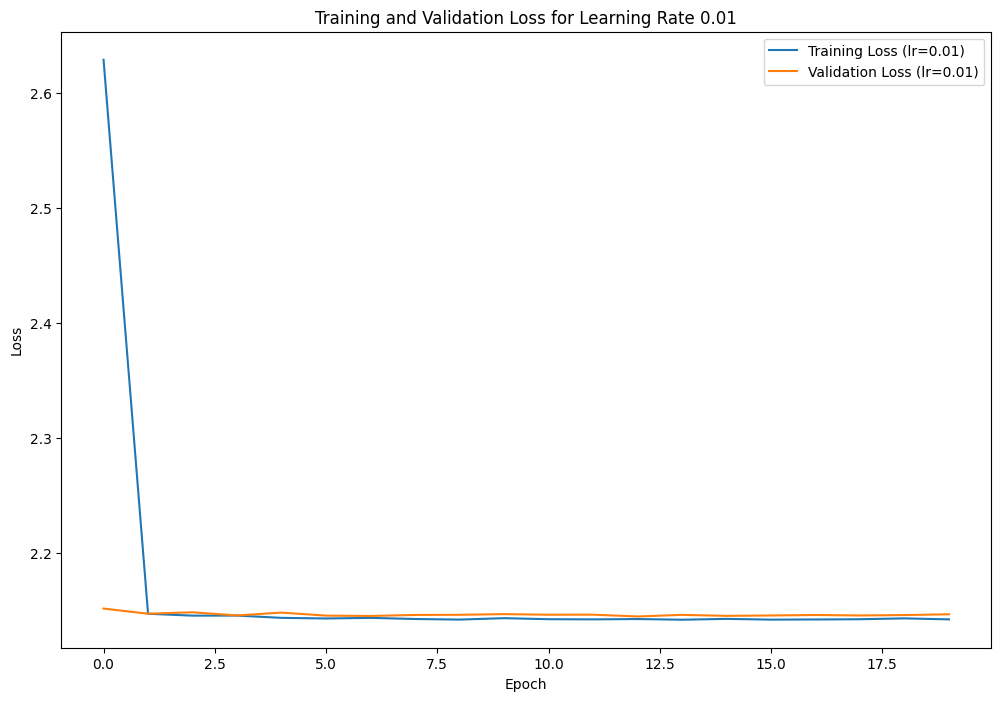

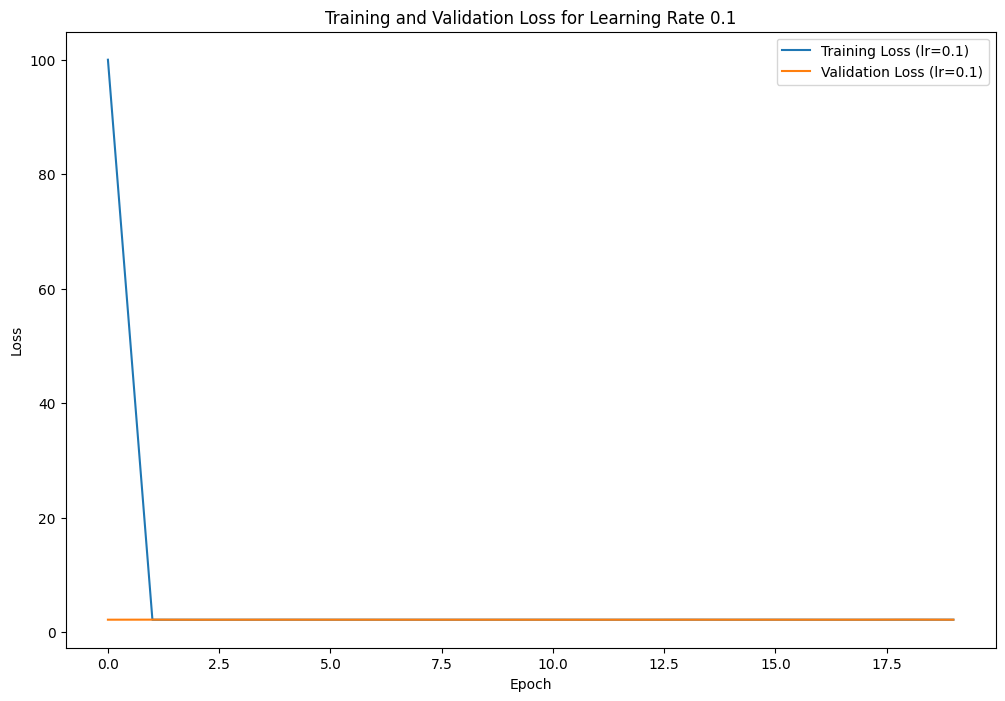

In [13]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
histories = []

for lr in learning_rates:
    # Build the CNN model
    model = models.Sequential()
    model.add(layers.Input(shape=(64, 64, 3)))
    model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(units=128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(units=9, activation='softmax'))
    
    # Compile the model with the current learning rate
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    history = model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator,
        verbose=1  # Display training progress
    )
    
    # Store the history
    histories.append(history)

# Plot the training and validation loss separately for each learning rate
for i, lr in enumerate(learning_rates):
    plt.figure(figsize=(12, 8))
    plt.plot(histories[i].history['loss'], label=f'Training Loss (lr={lr})')
    plt.plot(histories[i].history['val_loss'], label=f'Validation Loss (lr={lr})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training and Validation Loss for Learning Rate {lr}')
    plt.show()
